# Ejercicio 4: Modelo Probabilístico  
**Nombre:** Alexis Bautista  
**Fecha de Entrega:** 04 de mayo del 2026

## Objetivo de la práctica
- Comprender los componentes del modelo vectorial mediante cálculos manuales y observación directa.
- Aplicar el modelo de espacio vectorial con TF-IDF para recuperar documentos relevantes.
- Comparar la recuperación con BM25 frente a TF-IDF.
- Analizar visualmente las diferencias entre los modelos.
- Evaluar si los rankings generados son consistentes con lo que considerarías documentos relevantes.

In [26]:
#librerias a usar

import os
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer

import nltk
from nltk.corpus import stopwords

# Descargamos el diccionario de stopwords
nltk.download('stopwords', quiet=True) 

# Creamos la lista de stopwords en español
spanish_stopwords = stopwords.words('spanish')


from sklearn.metrics.pairwise import cosine_similarity
import numpy as np

import re
from collections import defaultdict

import matplotlib.pyplot as plt

## Parte 0: Carga del Corpus

Utilizaremos el corpus `Gutenberg 1000`

In [21]:
path = "data"
files = os.listdir(path)
N_archivos = len(files)

print ("El corpus tiene", N_archivos, "documentos")

# Carga de documentos
documentos = []
for archivo in files:
    with open(os.path.join(path, archivo), 'r', encoding='utf-8', errors='ignore') as f:
        documentos.append(f.read())

El corpus tiene 1000 documentos


## Parte 1: Cálculo de TF, DF, IDF y TF-IDF

### Actividad 
1. Construye la matriz de términos (TF), y calcula la frecuencia de documentos (DF)
2. Calcula TF-IDF utilizando sklearn.
3. Visualiza los valores en un DataFrame para analizar las diferencias entre los términos.

#### Indice invertido y Matriz TF

In [17]:
# Matriz TF e Índice invertido
count_vectorizer = CountVectorizer(max_features=1000, stop_words=spanish_stopwords)
matrizTF = count_vectorizer.fit_transform(documentos)
terminos = count_vectorizer.get_feature_names_out()

# Creacion indice invertido
indice_invertido = {}
for idx, termino in enumerate(terminos):
    # .nonzero()[0] obtiene los índices de los documentos donde aparece el termino
    docs_con_termino = matrizTF[:, idx].nonzero()[0]
    indice_invertido[termino] = docs_con_termino.tolist()

# Calculo DF
df = {}
for termino in terminos:
    df[termino] = len(indice_invertido[termino])

print("Ejemplo de DF para 5 terminos:")
print(list(df.items())[:5])

Ejemplo de DF para 5 terminos:
[('000', 395), ('10', 589), ('11', 572), ('12', 579), ('13', 535)]


Los resultados muestran exactamente en cuántos documentos distintos aparece cada término del corpus (por ejemplo, el término '10' se encontró en 589 textos).

#### TF-IDF

In [18]:
# TF-IDF
tfidf_vectorizer = TfidfVectorizer(max_features=1000, stop_words=spanish_stopwords)
matrizTFIDF = tfidf_vectorizer.fit_transform(documentos)

print("TF-IDF Matrix shape:", matrizTFIDF.shape)

# Dataframe para visualizar datos
tfidf_df = pd.DataFrame(
    matrizTFIDF[:5].toarray(), 
    columns=tfidf_vectorizer.get_feature_names_out(),
    index=[f"Doc_{i}" for i in range(min(5, N_archivos))] 
)

print("\nMuestra de TF-IDF (primeros 5 documentos y 10 términos):")
display(tfidf_df.iloc[:, :10])

TF-IDF Matrix shape: (1000, 1000)

Muestra de TF-IDF (primeros 5 documentos y 10 términos):


,000,10,11,12,13,14,15,16,17,18
Doc_0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.033909,0.000000,0.000000,0.000000
Doc_1,0.225652,0.049258,0.015060,0.011622,0.005235,0.006964,0.026155,0.030396,0.017817,0.014221
Doc_2,0.002257,0.007162,0.007299,0.005431,0.003806,0.011391,0.003565,0.005849,0.000000,0.001938
Doc_3,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
Doc_4,0.026001,0.025554,0.021017,0.019946,0.018105,0.015687,0.012497,0.013669,0.013621,0.012134


Los resultados representan el nivel de importancia de cada término dentro de un texto específico; un valor de 0.000000 indica que la palabra no aparece, mientras que los decimales mayores señalan que ese término es más distintivo y relevante para ese documento en particular.

Nota: Obtenemos estos números como terminos por el comportamiento por defecto de sklearn

## Parte 2: Ranking de documentos usando TF-IDF

### Actividad 

1. Dada una consulta, construye el vector de consulta
2. Calcula la similitud coseno entre la consulta y cada documento usando los vectores TF-IDF
3. Genera un ranking de los documentos ordenados por relevancia.
4. Muestra los resultados en una tabla.

In [23]:
# Definir una consulta
consulta = "amor y pasión en la literatura"

# Construir el vector de consulta usando el mismo vectorizador TF-IDF
consulta_vector = tfidf_vectorizer.transform([consulta])

# Calcular similitud coseno entre la consulta y todos los documentos
similitudes = cosine_similarity(consulta_vector, matrizTFIDF)[0]

# Crear un ranking ordenado por relevancia
ranking_indices = np.argsort(similitudes)[::-1]  # Ordenar de mayor a menor
ranking_scores = similitudes[ranking_indices]

# Crear un DataFrame con los resultados
ranking_df = pd.DataFrame({
    'Documento': [f"Doc_{i}" for i in ranking_indices],
    'Archivo': [files[i] for i in ranking_indices],
    'Similitud': ranking_scores
})

# Mostrar los top 10 documentos más relevantes
print(f"Consulta: '{consulta}'\n")
print("Top 10 documentos más relevantes (TF-IDF):")
display(ranking_df.head(10))

Consulta: 'amor y pasión en la literatura'

Top 10 documentos más relevantes (TF-IDF):


,Documento,Archivo,Similitud
0,Doc_266,El infierno del amor leyenda fantastica.txt,0.392063
1,Doc_626,Lira Póstuma Obras Completas Vol. XXI.txt,0.294074
2,Doc_32,Amores elegías amatorias.txt,0.270460
3,Doc_777,Parnaso Filipino Antología de Poetas del Archi...,0.262148
4,Doc_444,"Impresiones, Poesías.txt",0.257931
5,Doc_723,Místicas; poesías.txt,0.255630
6,Doc_802,Prosas Profanas Obras Completas Vol. II.txt,0.252875
7,Doc_136,Cuentos de poeta.txt,0.248865
8,Doc_790,Poema del Otoño y otros poemas Obras Completas...,0.243953
9,Doc_50,Ausías March y su época.txt,0.239131


El ranking demuestra que el modelo posicionó en la cima a libros de romance y poesía, liderados por *El infierno del amor*, porque la métrica de similitud coseno identificó en sus vectores la mayor densidad matemática de los términos más valiosos y discriminantes de tu búsqueda (como "amor" y "pasión").

## Parte 3: Ranking con BM25

### Actividad 

1. Implementa un sistema de recuperación usando el modelo BM25.
2. Usa la misma consulta del ejercicio anterior.
3. Calcula el score BM25 para cada documento y genera un ranking.
4. Compara manualmente con el ranking de TF-IDF.

### Algoritmo BM25:

1. Tokenización
2. Calcular longitudes de documentos y promedio de longitud
3. Calcular TF (frecuencia de término por documento)
4. Calcular DF (document frequency) e IDF de BM25
5. Definir los parámetros de BM25 (k1, b)
6. Implementar la función de score BM25 para un documento
7. Función para calcular la probabilidad para todos los documentos de la colección a partir de una query
8. Recuperar los documentos mejor puntuados (ranking)

In [25]:
### Implementación de BM25

# 1. Tokenización
def tokenizar(texto):
    """Tokeniza un texto en palabras y lo convierte a minúsculas"""
    texto = texto.lower()
    palabras = re.findall(r'\b\w+\b', texto)
    return [p for p in palabras if p not in spanish_stopwords]

# Tokenizar todos los documentos
docs_tokenizados = [tokenizar(doc) for doc in documentos]

# 2. Calcular longitudes de documentos y promedio
doc_lengths = [len(doc) for doc in docs_tokenizados]
avgdl = sum(doc_lengths) / len(doc_lengths)

# 3. Calcular TF por documento
def calcular_tf(doc):
    """Calcula la frecuencia de términos en un documento"""
    tf = defaultdict(int)
    for palabra in doc:
        tf[palabra] += 1
    return tf

tf_docs = [calcular_tf(doc) for doc in docs_tokenizados]

# 4. Calcular DF e IDF de BM25
def calcular_idf_bm25(termino, N, df_termino):
    """Calcula IDF usando la fórmula de BM25"""
    return np.log((N - df_termino + 0.5) / (df_termino + 0.5) + 1)

# 5. Parámetros BM25
k1 = 1.5  # Controla la saturación de la frecuencia del término
b = 0.75  # Controla el impacto de la longitud del documento

# 6. Función de score BM25 para un documento
def score_bm25_doc(query_terms, doc_idx, tf_docs, doc_lengths, avgdl, k1, b, N, df_dict):
    """Calcula el score BM25 para un documento dado una query"""
    score = 0
    for term in query_terms:
        if term in tf_docs[doc_idx]:
            tf = tf_docs[doc_idx][term]
            df = df_dict.get(term, 0)
            if df > 0:
                idf = calcular_idf_bm25(term, N, df)
                numerador = tf * (k1 + 1)
                denominador = tf + k1 * (1 - b + b * (doc_lengths[doc_idx] / avgdl))
                score += idf * (numerador / denominador)
    return score

# 7. Función para calcular scores BM25 para todos los documentos
def ranking_bm25(consulta, docs_tokenizados, tf_docs, doc_lengths, avgdl, k1, b, spanish_stopwords):
    """Genera un ranking BM25 para una consulta"""
    N = len(docs_tokenizados)
    
    # Tokenizar consulta
    query_terms = tokenizar(consulta)
    
    # Calcular DF para términos de la query
    df_dict = defaultdict(int)
    for term in query_terms:
        for doc_idx in range(N):
            if term in tf_docs[doc_idx]:
                df_dict[term] += 1
    
    # Calcular scores BM25 para todos los documentos
    scores = []
    for doc_idx in range(N):
        score = score_bm25_doc(query_terms, doc_idx, tf_docs, doc_lengths, avgdl, k1, b, N, df_dict)
        scores.append(score)
    
    return np.array(scores)

# 8. Aplicar BM25 a la misma consulta
scores_bm25 = ranking_bm25(consulta, docs_tokenizados, tf_docs, doc_lengths, avgdl, k1, b, spanish_stopwords)

# Crear ranking ordenado
ranking_indices_bm25 = np.argsort(scores_bm25)[::-1]
ranking_scores_bm25 = scores_bm25[ranking_indices_bm25]

# Crear DataFrame con resultados BM25
ranking_df_bm25 = pd.DataFrame({
    'Documento': [f"Doc_{i}" for i in ranking_indices_bm25],
    'Archivo': [files[i] for i in ranking_indices_bm25],
    'Score BM25': ranking_scores_bm25
})

# Mostrar top 10
print(f"Consulta: '{consulta}'\n")
print("Top 10 documentos más relevantes (BM25):")
display(ranking_df_bm25.head(10))

Consulta: 'amor y pasión en la literatura'

Top 10 documentos más relevantes (BM25):


,Documento,Archivo,Score BM25
0,Doc_412,Historia de la literatura y del arte dramático...,3.314623
1,Doc_619,Letras Obras Completas Vol. VIII.txt,3.313448
2,Doc_767,"Orígenes de la novela, Tomo I.txt",3.309457
3,Doc_672,Los Raros Obras Completas Vol. VI.txt,3.288273
4,Doc_414,Historia de la literatura y del arte dramático...,3.277731
5,Doc_313,El Superhombre y otras novedades.txt,3.267583
6,Doc_415,Historia de la literatura y del arte dramático...,3.260137
7,Doc_50,Ausías March y su época.txt,3.258467
8,Doc_607,"Las máscaras, vol. 12.txt",3.246214
9,Doc_74,Cartas americanas. Primera serie.txt,3.241922


TF-IDF se dejó llevar por la intensidad (Poesía/Romance): El ranking de TF-IDF posicionó en la cima textos poéticos y románticos (como El infierno del amor o Amores elegías). Esto ocurre porque en TF-IDF la relevancia crece de forma casi lineal con la repetición; los poemas, al ser más cortos y repetir intensamente las palabras "amor" y "pasión", dispararon su puntuación.

BM25 priorizó el contexto y la exhaustividad (Historia/Análisis): El ranking de BM25 cambió drásticamente hacia textos analíticos y extensos (como Historia de la literatura... u Orígenes de la novela). Esto demuestra en la práctica las dos grandes ventajas de BM25:

- Saturación de frecuencia (k1): BM25 puso un límite a la "ganancia" de repetir "amor" o "pasión" muchas veces en un poema, obligando al modelo a buscar documentos que también incluyeran la palabra "literatura".  

- Normalización de longitud (b): A diferencia de TF-IDF, BM25 no penalizó a los libros de historia extensos por tener miles de palabras, permitiendo que obras completas que discuten todos los términos de la consulta dominen el Top 10 de manera mucho más equilibrada.  

**En resumen: TF-IDF encontró los textos más apasionados, pero BM25 encontró los textos más informativos y completos sobre el tema de tu búsqueda.**

## Parte 4: Comparación visual entre TF-IDF y BM25

### Actividad 

1. Utiliza un gráfico de barras para visualizar los scores obtenidos por cada documento según TF-IDF y BM25.
2. Compara los rankings visualmente.
3. ¿Qué documentos obtienen scores más altos en un modelo que en otro?
4. ¿A qué se podría deber esta diferencia?

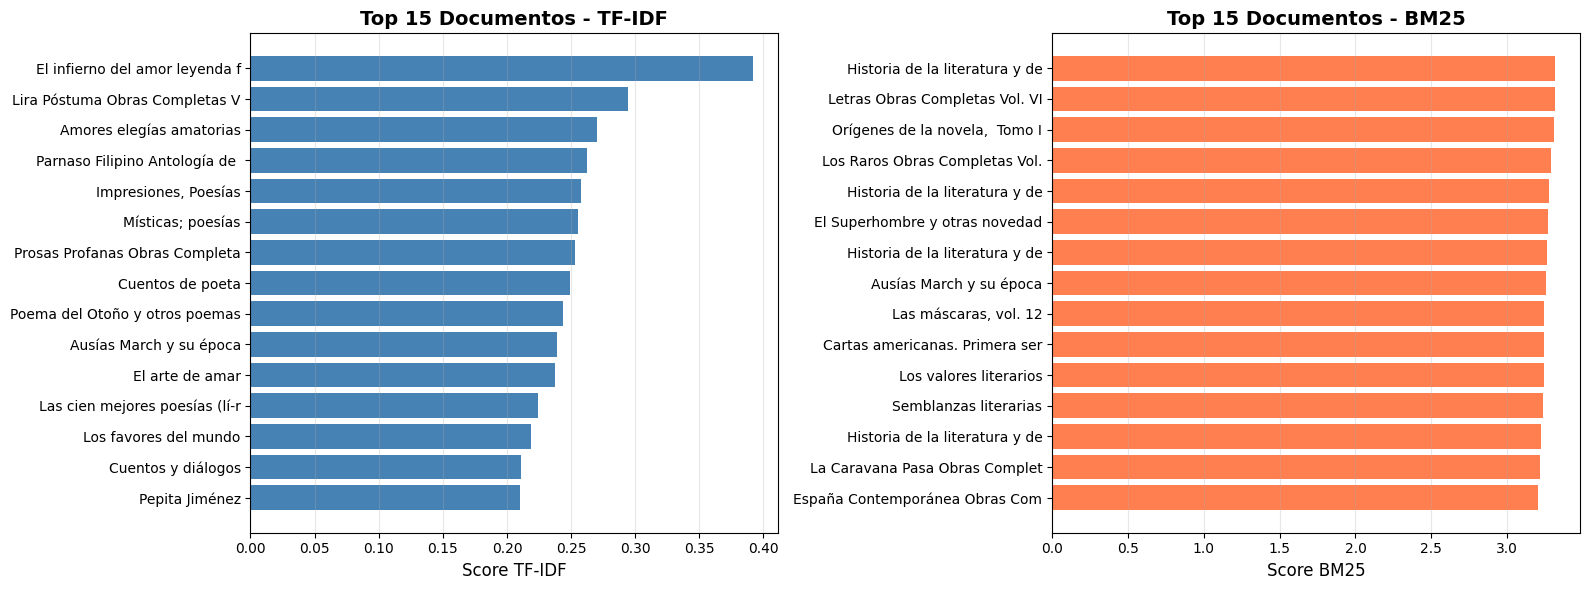


COMPARACIÓN TOP 10: TF-IDF vs BM25


,Ranking TF-IDF,Score TF-IDF,Ranking BM25,Score BM25
0,1. El infierno del amor leyenda fantastica,0.392063,1. Historia de la literatura y del arte dra,3.314623
1,2. Lira Póstuma Obras Completas Vol. XXI,0.294074,2. Letras Obras Completas Vol. VIII,3.313448
2,3. Amores elegías amatorias,0.270460,"3. Orígenes de la novela, Tomo I",3.309457
3,4. Parnaso Filipino Antología de Poetas del,0.262148,4. Los Raros Obras Completas Vol. VI,3.288273
4,"5. Impresiones, Poesías",0.257931,5. Historia de la literatura y del arte dra,3.277731
5,6. Místicas; poesías,0.255630,6. El Superhombre y otras novedades,3.267583
6,7. Prosas Profanas Obras Completas Vol. II,0.252875,7. Historia de la literatura y del arte dra,3.260137
7,8. Cuentos de poeta,0.248865,8. Ausías March y su época,3.258467
8,9. Poema del Otoño y otros poemas Obras Com,0.243953,"9. Las máscaras, vol. 12",3.246214
9,10. Ausías March y su época,0.239131,10. Cartas americanas. Primera serie,3.241922



Documentos en Top 10 de ambos modelos: 1/10
- Ausías March y su época.txt: Posición TF-IDF #10, Posición BM25 #8


In [27]:
# Preparar datos para la comparación visual
top_n = 15
top_indices_tfidf = ranking_indices[:top_n]
top_indices_bm25 = ranking_indices_bm25[:top_n]

# Crear figura con dos subgráficos
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Gráfico 1: TF-IDF
axes[0].barh(range(top_n), ranking_scores[:top_n], color='steelblue')
axes[0].set_yticks(range(top_n))
axes[0].set_yticklabels([files[i].replace('.txt', '')[:30] for i in top_indices_tfidf])
axes[0].set_xlabel('Score TF-IDF', fontsize=12)
axes[0].set_title('Top 15 Documentos - TF-IDF', fontsize=14, fontweight='bold')
axes[0].invert_yaxis()
axes[0].grid(axis='x', alpha=0.3)

# Gráfico 2: BM25
axes[1].barh(range(top_n), ranking_scores_bm25[:top_n], color='coral')
axes[1].set_yticks(range(top_n))
axes[1].set_yticklabels([files[i].replace('.txt', '')[:30] for i in top_indices_bm25])
axes[1].set_xlabel('Score BM25', fontsize=12)
axes[1].set_title('Top 15 Documentos - BM25', fontsize=14, fontweight='bold')
axes[1].invert_yaxis()
axes[1].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

# Tabla comparativa de los top 10
print("\n" + "="*80)
print("COMPARACIÓN TOP 10: TF-IDF vs BM25")
print("="*80)

comparacion_df = pd.DataFrame({
    'Ranking TF-IDF': [f"{i+1}. {files[ranking_indices[i]].replace('.txt', '')[:40]}" for i in range(10)],
    'Score TF-IDF': ranking_scores[:10],
    'Ranking BM25': [f"{i+1}. {files[ranking_indices_bm25[i]].replace('.txt', '')[:40]}" for i in range(10)],
    'Score BM25': ranking_scores_bm25[:10]
})

display(comparacion_df)

# Análisis de coincidencias
top_10_tfidf = set(ranking_indices[:10])
top_10_bm25 = set(ranking_indices_bm25[:10])
coincidencias = top_10_tfidf.intersection(top_10_bm25)

print("\n" + "="*80)
print(f"Documentos en Top 10 de ambos modelos: {len(coincidencias)}/10")
print("="*80)
for doc_idx in coincidencias:
    tfidf_pos = list(ranking_indices[:10]).index(doc_idx) + 1
    bm25_pos = list(ranking_indices_bm25[:10]).index(doc_idx) + 1
    print(f"- {files[doc_idx]}: Posición TF-IDF #{tfidf_pos}, Posición BM25 #{bm25_pos}")

**3. ¿Qué documentos obtienen scores más altos en un modelo que en otro?**

Al observar la tabla comparativa, la divergencia entre ambos modelos es casi total (solo comparten 1 de 10 documentos en el Top 10):

*   **Dominio en TF-IDF:** Los documentos que obtienen los scores más altos en este modelo son casi exclusivamente obras de poesía, leyendas y romance (ej. *El infierno del amor leyenda fantastica*, *Lira Póstuma*, *Amores elegías amatorias*). Estos textos no logran entrar al Top 10 de BM25.
*   **Dominio en BM25:** Por el contrario, los documentos que dominan este ranking son textos académicos, históricos y antologías extensas (ej. *Historia de la literatura y del arte dramático*, *Orígenes de la novela, Tomo I*). Estos textos fueron ignorados por el Top 10 de TF-IDF.
*   **La excepción (El punto medio):** El único documento que obtiene un score competitivo en ambos modelos es *Ausías March y su época* (posición #10 en TF-IDF y #8 en BM25), sugiriendo que es un texto que equilibra una alta repetición de palabras clave con una longitud o estructura que agrada a ambos algoritmos.

**4. ¿A qué se podría deber esta diferencia?**

Esta diferencia visualiza perfectamente la teoría matemática detrás de ambos modelos:

*   **Falta de límites en TF-IDF:** El modelo TF-IDF básico recompensa la repetición pura. Un poema corto que repita las palabras "amor" y "pasión" 30 veces obtendrá un puntaje altísimo, eclipsando por completo la ausencia de la palabra "literatura".
*   **Saturación de Frecuencia en BM25 ($k_1$):** BM25 introduce un límite matemático a la repetición. Repetir "amor" 30 veces en un poema ya no suma más puntos que repetirla 10 veces. Para lograr un score alto en BM25, el documento se ve "obligado" a contener también los otros términos de tu consulta (como "literatura"), lo que favorece a los libros de historia o crítica literaria que abordan todos los temas.
*   **Normalización por Longitud en BM25 ($b$):** Un libro como *Historia de la literatura...* es masivo en cantidad de palabras. TF-IDF suele diluir el peso de las palabras clave en textos tan largos, pero BM25 utiliza el parámetro $b$ para compensar este efecto de manera más inteligente, permitiendo que libros gigantescos compitan de forma justa contra poemas cortos si su contenido es realmente relevante.